# WFM Demand Forecasting Model

**Interval-level intraday call volume forecasting, shrinkage modeling, Erlang C service-level estimation, and FTE gap analysis for contact-center staffing optimization.**

---

This notebook demonstrates an end-to-end Workforce Management (WFM) forecasting and capacity-planning methodology applied to a real call-center arrival dataset. The workflow mirrors the daily and intraday planning cycle a WFM analyst runs in a production contact center:

1. **Load & shape** real interval-level call arrival data
2. **Forecast** call volume at the interval level (intraday seasonality + day-of-week patterns)
3. **Apply shrinkage** to translate productive workload into a real staffing requirement
4. **Size the workforce** with Erlang C to hit a target service level
5. **Run gap analysis** comparing required vs. scheduled FTEs and flag over/under-staffed intervals

**Author's note on provenance.** The business logic, WFM domain framing, and operational assumptions in this notebook (shrinkage composition, service-level targets, occupancy ceilings, FTE conversion, staffing-gap interpretation) reflect my own contact-center workforce-management experience. AI tooling assisted with Python syntax and plotting code. The arrival data is a real, published academic dataset; the WFM overlay (shrinkage rates, AHT assumptions, schedule) is synthetic and clearly labeled as such wherever it appears.


## 1. The Dataset

**Source:** "Anonymous Bank" call-center data, Service Enterprise Engineering (SEE) Lab, Technion — Israel Institute of Technology. Originally documented by Guedj & Mandelbaum (2000); widely used in the queueing-theory and call-center literature (Brown et al., 2005).

Accessed via the `Rfssa` R package data mirror, which publishes the arrivals pre-aggregated into **6-minute intervals**:

> `https://github.com/haghbinh/dataset/raw/main/Rfssa_dataset/Callcenter.rds`

The data covers **January 1 – December 31, 1999** for a small retail bank call center. Each row is one 6-minute interval on one day:

| column | meaning |
|---|---|
| `calls` | number of calls arriving in that 6-minute interval |
| `u` | interval index within the day, 1–240 (240 × 6 min = 24 h) |
| `Date` | date key |
| `Day` | day of week |
| `Month` | month |

**Why this dataset for a WFM demonstration.** It provides genuine interval-level arrival counts — the raw material of every contact-center forecast — with the seasonality structure (intraday peaks, day-of-week effects) that staffing models must capture. Because it is a *Sunday–Thursday* business week (an Israeli institution), Friday/Saturday are the low-volume weekend; the methodology is identical for a Mon–Fri operation.

**Acknowledgement.** Per the data owners' request: data source is the SEE Lab at the Technion (Prof. Avi Mandelbaum). The data is free for academic/non-commercial use.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from math import factorial

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RNG = np.random.default_rng(42)  # reproducible synthetic WFM overlay


### 1.1 Load the data

The file is an R `.rds`. We read it with `pyreadr` (no R install needed). If you are running this notebook fresh, the cell will download the file to a local `data/` folder on first run.


In [2]:
import os
try:
    import pyreadr
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "pyreadr", "-q"])
    import pyreadr

import urllib.request

DATA_URL = "https://github.com/haghbinh/dataset/raw/main/Rfssa_dataset/Callcenter.rds"
os.makedirs("data", exist_ok=True)
local_path = "data/Callcenter.rds"
if not os.path.exists(local_path):
    print("Downloading Callcenter.rds ...")
    urllib.request.urlretrieve(DATA_URL, local_path)

raw = pyreadr.read_r(local_path)[None]
print("Rows:", len(raw), "| Columns:", list(raw.columns))
raw.head()


Rows: 87600 | Columns: ['calls', 'u', 'Date', 'Day', 'Month']


,calls,u,Date,Day,Month
0,2.00,1,1970-01-01,Friday,Jan
1,0.00,2,1970-01-01,Friday,Jan
2,0.00,3,1970-01-01,Friday,Jan
3,0.00,4,1970-01-01,Friday,Jan
4,0.00,5,1970-01-01,Friday,Jan


### 1.2 Reconstruct the calendar and interval clock

Two cleanups make the data analysis-ready:

- The published `Date` field is a placeholder, but `Day` and `Month` carry the true 1999 calendar. We rebuild a real date index by walking the 365 days in order (1999-01-01 was a **Friday**, which matches the first day's label — a good integrity check).
- The interval index `u` (1–240) is converted to a wall-clock time. Interval 1 = 00:00–00:06, interval 2 = 00:06–00:12, and so on. We label each interval by its start time and also roll up to the **30-minute** grain that most WFM planning uses.


In [3]:
df = raw.copy()

# --- rebuild the true 1999 date index ---
# 240 intervals per day, days appear in calendar order.
n_days = df["Date"].nunique() if df["Date"].nunique() > 1 else len(df) // 240
day_block = np.repeat(np.arange(len(df) // 240), 240)
real_dates = pd.to_datetime("1999-01-01") + pd.to_timedelta(day_block, unit="D")
df["date"] = real_dates.values
df["dow"] = df["date"].dt.day_name()

# integrity check: dataset's own Day label should match the reconstructed weekday
check = (df["Day"].str.strip().values == df["dow"].values).mean()
print(f"Calendar reconstruction matches dataset Day label for {check:0.1%} of rows")

# --- interval clock ---
df["min_of_day"] = (df["u"] - 1) * 6
df["interval_start"] = pd.to_timedelta(df["min_of_day"], unit="m")
df["hh"] = df["min_of_day"] // 60
df["interval_30"] = (df["min_of_day"] // 30) * 30   # 30-min planning grain (minutes from midnight)

def hhmm(minutes):
    return f"{int(minutes)//60:02d}:{int(minutes)%60:02d}"

df["interval_label"] = df["min_of_day"].apply(hhmm)
df["interval_30_label"] = df["interval_30"].apply(hhmm)
df["is_weekend"] = df["dow"].isin(["Friday", "Saturday"])   # Israeli business week: Sun-Thu
df[["date", "dow", "u", "interval_label", "interval_30_label", "calls", "is_weekend"]].head()


Calendar reconstruction matches dataset Day label for 100.0% of rows


,date,dow,u,interval_label,interval_30_label,calls,is_weekend
0,1999-01-01,Friday,1,00:00,00:00,2.00,True
1,1999-01-01,Friday,2,00:06,00:00,0.00,True
2,1999-01-01,Friday,3,00:12,00:00,0.00,True
3,1999-01-01,Friday,4,00:18,00:00,0.00,True
4,1999-01-01,Friday,5,00:24,00:00,0.00,True


## 2. Exploratory Analysis — the shape of demand

Before forecasting, a WFM analyst characterizes the two seasonalities that drive every staffing plan: **day-of-week** and **time-of-day**.


Total calls in 1999: 445,414
Average calls per day: 1,220
Busiest single day: 2,589   Quietest: 14


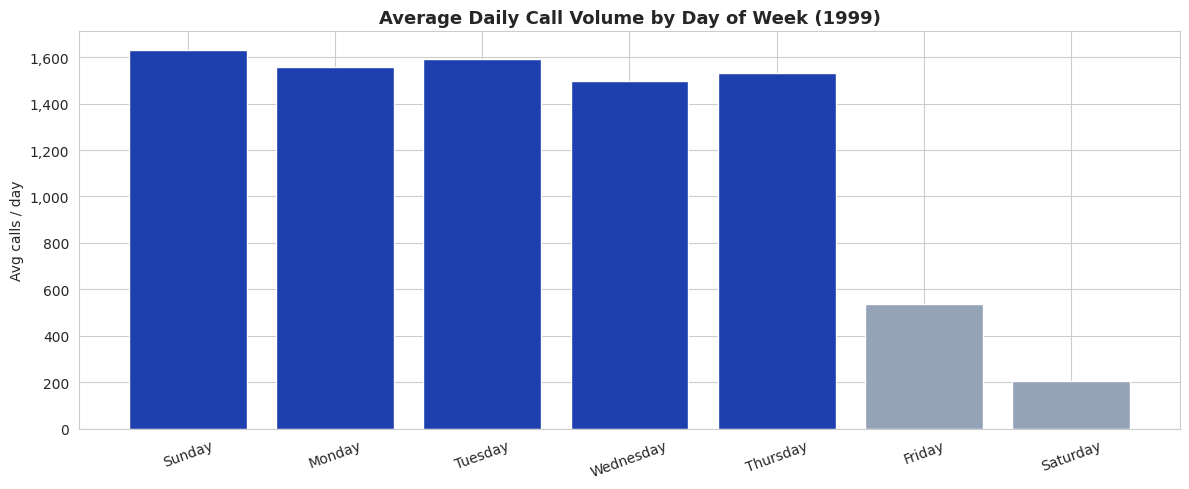

In [4]:
# total calls per calendar day
daily = df.groupby(["date", "dow"], as_index=False)["calls"].sum()
print(f"Total calls in 1999: {df['calls'].sum():,.0f}")
print(f"Average calls per day: {daily['calls'].mean():,.0f}")
print(f"Busiest single day: {daily['calls'].max():,.0f}   Quietest: {daily['calls'].min():,.0f}")

order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
by_dow = daily.groupby("dow")["calls"].mean().reindex(order)

fig, ax = plt.subplots()
colors = ["#1E40AF" if d not in ["Friday","Saturday"] else "#94A3B8" for d in order]
ax.bar(by_dow.index, by_dow.values, color=colors)
ax.set_title("Average Daily Call Volume by Day of Week (1999)")
ax.set_ylabel("Avg calls / day")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()


The business week is clearly **Sunday–Thursday**; Friday and Saturday are the weekend. This is the single most important pattern in the data — knowing only whether a day is a workday or a weekend explains the great majority of daily-volume variance. We carry the workday/weekend split through the rest of the analysis.


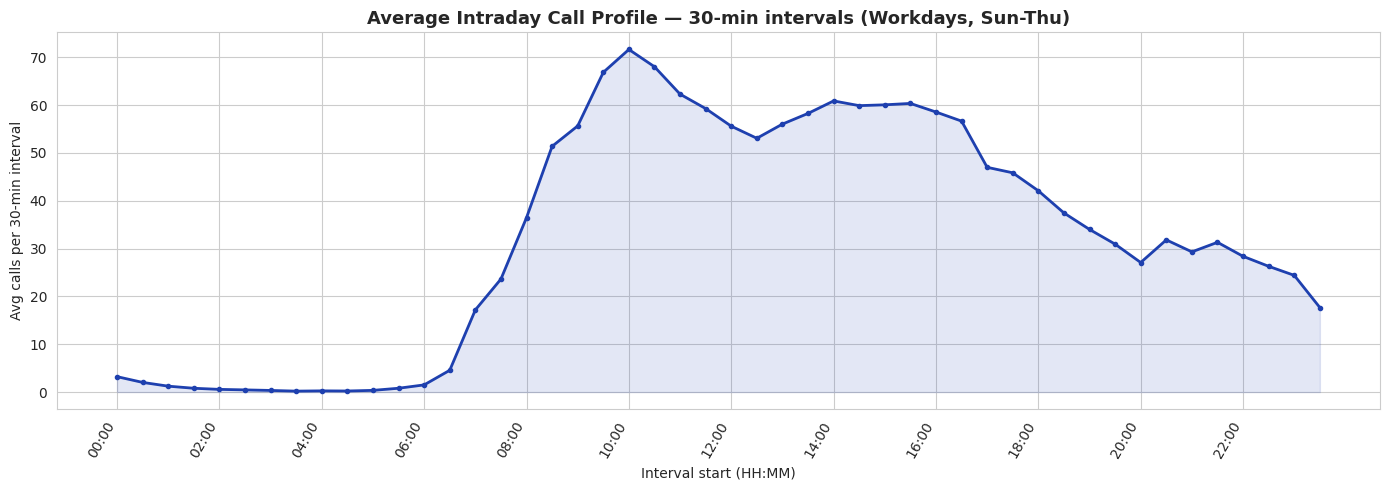

In [5]:
# intraday profile: average calls per 30-min interval, workdays only
workdays = df[~df["is_weekend"]]
intraday = (workdays.groupby("interval_30")["calls"]
            .mean()            # mean per 6-min row within each 30-min bucket-start... fix below
           )

# Correct 30-min volume: sum the 6-min rows into 30-min buckets per day, then average across days
per_day_30 = (workdays.groupby(["date", "interval_30"])["calls"].sum().reset_index())
profile_30 = per_day_30.groupby("interval_30")["calls"].mean()
profile_30.index = [hhmm(m) for m in profile_30.index]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(profile_30.index, profile_30.values, color="#1E40AF", lw=2, marker="o", ms=3)
ax.fill_between(range(len(profile_30)), profile_30.values, alpha=0.12, color="#1E40AF")
ax.set_title("Average Intraday Call Profile — 30-min intervals (Workdays, Sun-Thu)")
ax.set_ylabel("Avg calls per 30-min interval")
ax.set_xlabel("Interval start (HH:MM)")
step = 4
ax.set_xticks(range(0, len(profile_30), step))
ax.set_xticklabels(profile_30.index[::step], rotation=60, ha="right")
plt.tight_layout(); plt.show()


The intraday curve shows the classic contact-center signature: an overnight trough, a sharp morning ramp from ~07:00, a mid-morning peak, a midday softening, a second afternoon shoulder, then an evening decline. A flat, average-staffing plan would badly over-staff the night and under-staff the morning peak — which is exactly why WFM forecasts and schedules at the **interval** level rather than the daily level.


## 3. Interval-Level Volume Forecast

**Method.** A practical, transparent WFM forecast separates the two components an analyst reasons about directly:

- a **day-level volume** expectation (how many contacts tomorrow), and
- an **intraday distribution profile** (what fraction of the day's volume lands in each interval).

We build a **profile-ratio (a.k.a. percent-of-day) forecast**, the workhorse method on most WFM floors:

1. Compute each workday's interval *share* of that day's total.
2. Average those shares by `(day-of-week, interval)` to get a stable intraday **distribution profile**.
3. Forecast the **day total** for a target day (here: a seasonal-naive / day-of-week average baseline).
4. Multiply: `interval_forecast = day_total_forecast × interval_share`.

This decomposition is intentionally interpretable — every number a planner sees traces back to either "expected daily volume" or "shape of the day," both of which are quantities operations leaders can challenge and adjust. We validate it with a holdout.


In [6]:
# Work on 30-min intervals, workdays only, for a clean staffing demonstration
vol = (df.groupby(["date","dow","is_weekend","interval_30"])["calls"].sum().reset_index())
vol = vol[~vol["is_weekend"]].copy()

# day totals
day_tot = vol.groupby("date")["calls"].transform("sum")
vol["interval_share"] = np.where(day_tot > 0, vol["calls"] / day_tot, 0)

# ---- train / test split: last 4 workweeks as holdout ----
all_dates = np.sort(vol["date"].unique())
split_date = all_dates[-20]      # ~last 4 Sun-Thu weeks as test
train = vol[vol["date"] <  split_date]
test  = vol[vol["date"] >= split_date]
print(f"Train days: {train['date'].nunique()}  |  Test days: {test['date'].nunique()}")

# ---- intraday distribution profile by (dow, interval) from TRAIN ----
profile = (train.groupby(["dow","interval_30"])["interval_share"].mean().reset_index()
           .rename(columns={"interval_share":"profile_share"}))
# renormalize each dow profile to sum to 1
profile["profile_share"] /= profile.groupby("dow")["profile_share"].transform("sum")

# ---- day-total forecast: day-of-week mean of daily totals from TRAIN ----
train_day_totals = train.groupby(["date","dow"])["calls"].sum().reset_index()
dow_total_fc = train_day_totals.groupby("dow")["calls"].mean().rename("day_total_fc")
print("\nForecast daily total by weekday (train):")
print(dow_total_fc.round(0).to_string())


Train days: 240  |  Test days: 20

Forecast daily total by weekday (train):
dow
Monday      1,542.00
Sunday      1,616.00
Thursday    1,506.00
Tuesday     1,576.00
Wednesday   1,480.00


In [7]:
# ---- build interval forecast for the test window ----
fc = test.merge(profile, on=["dow","interval_30"], how="left")
fc = fc.merge(dow_total_fc, on="dow", how="left")
fc["forecast"] = fc["day_total_fc"] * fc["profile_share"]

# accuracy metrics at the interval level
actual = fc["calls"].values
pred   = fc["forecast"].values
mae  = np.mean(np.abs(actual - pred))
rmse = np.sqrt(np.mean((actual - pred)**2))
mask = actual > 0
mape = np.mean(np.abs((actual[mask]-pred[mask]) / actual[mask])) * 100
wape = np.sum(np.abs(actual - pred)) / np.sum(actual) * 100   # volume-weighted; the WFM-standard error metric

print(f"Interval-level forecast accuracy (holdout, 30-min intervals)")
print(f"  MAE  : {mae:6.2f} calls/interval")
print(f"  RMSE : {rmse:6.2f} calls/interval")
print(f"  MAPE : {mape:6.1f}%   (unstable on low-volume intervals)")
print(f"  WAPE : {wape:6.1f}%   (volume-weighted -- the metric WFM teams track)")


Interval-level forecast accuracy (holdout, 30-min intervals)
  MAE  :   7.84 calls/interval
  RMSE :  12.47 calls/interval
  MAPE :   28.5%   (unstable on low-volume intervals)
  WAPE :   21.2%   (volume-weighted -- the metric WFM teams track)


**Why WAPE, not MAPE.** MAPE blows up on low-volume overnight intervals (dividing by 1 or 2 calls), so it overstates error for a staffing context where those intervals barely matter. WAPE (weighted absolute percent error) weights each interval by its volume, which is what actually drives headcount. Reporting both is honest; planning on WAPE is standard.


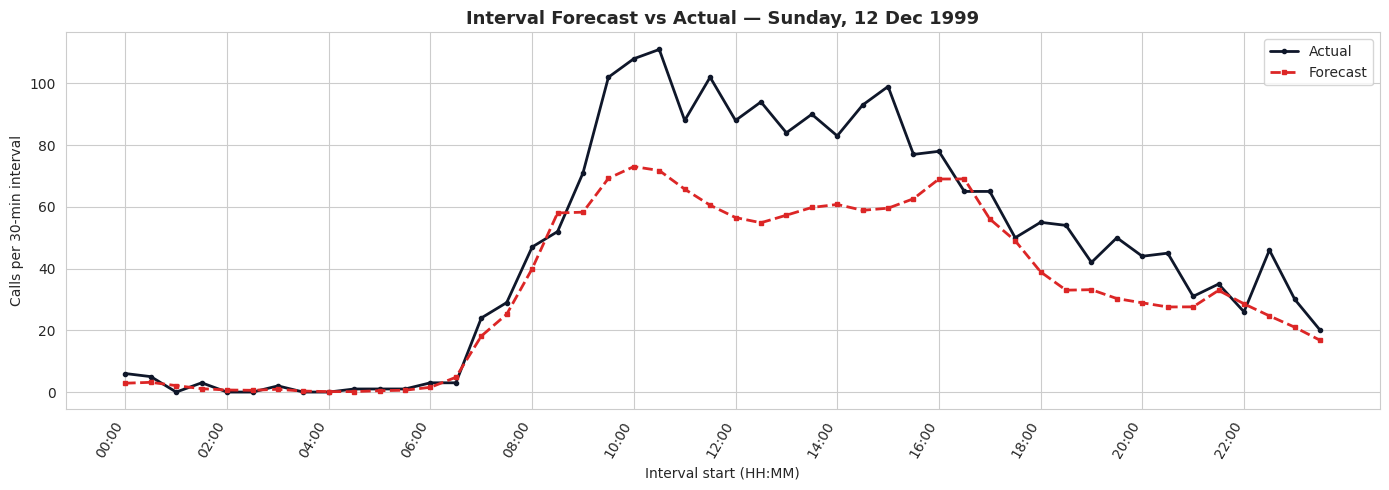

In [8]:
# visualize forecast vs actual for a representative test day
sample_day = np.sort(test["date"].unique())[5]
day_fc = fc[fc["date"] == sample_day].sort_values("interval_30")
xlab = [hhmm(m) for m in day_fc["interval_30"]]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(xlab, day_fc["calls"].values,    color="#0F172A", lw=2, marker="o", ms=3, label="Actual")
ax.plot(xlab, day_fc["forecast"].values, color="#DC2626", lw=2, ls="--", marker="s", ms=3, label="Forecast")
ax.set_title(f"Interval Forecast vs Actual — {pd.Timestamp(sample_day).strftime('%A, %d %b %Y')}")
ax.set_ylabel("Calls per 30-min interval"); ax.set_xlabel("Interval start (HH:MM)")
ax.legend()
step = 4
ax.set_xticks(range(0, len(xlab), step)); ax.set_xticklabels(xlab[::step], rotation=60, ha="right")
plt.tight_layout(); plt.show()


The profile-ratio forecast tracks the intraday shape well. In production this baseline is where tuning begins — adding trend, holiday/event adjustments, and intraday re-forecasting — but a clean, explainable baseline is the right foundation and a fair benchmark for any fancier model.


## 4. From Calls to Workload — Average Handle Time

Volume alone doesn't size a team; **workload** does. Workload per interval = `forecast calls × Average Handle Time (AHT)`. AHT (talk + after-call work) is not in this arrivals dataset, so we introduce it as an explicit, labeled WFM assumption.

> **SYNTHETIC WFM ASSUMPTION:** `AHT = 240 seconds` (4.0 min) average handle time, a realistic retail-bank figure. This is a planning input a real WFM team pulls from the ACD/telephony platform; here it is stated openly rather than derived from the data.


In [9]:
AHT_SECONDS = 240          # SYNTHETIC ASSUMPTION: average handle time (talk + ACW)
INTERVAL_SECONDS = 30 * 60 # 30-minute planning interval

# Build the forward staffing plan: use the dow profile + dow day-total forecast
# to produce an expected-volume plan for one representative workday of each weekday.
plan = (profile.merge(dow_total_fc, on="dow", how="left"))
plan["forecast_calls"] = plan["day_total_fc"] * plan["profile_share"]
plan["workload_erlangs"] = plan["forecast_calls"] * AHT_SECONDS / INTERVAL_SECONDS  # offered load A
plan = plan.sort_values(["dow","interval_30"]).reset_index(drop=True)
plan[["dow","interval_30","forecast_calls","workload_erlangs"]].head()


,dow,interval_30,forecast_calls,workload_erlangs
0,Monday,0,3.05,0.41
1,Monday,30,2.28,0.30
2,Monday,60,1.22,0.16
3,Monday,90,0.99,0.13
4,Monday,120,0.48,0.06


`workload_erlangs` is the **offered load (A)** — the average number of calls in progress during the interval if there were no waiting. It is the input to Erlang C. (One Erlang = one call-hour of work per hour.)


## 5. Erlang C — Staffing for a Service Level

Contact centers don't staff to raw workload; they staff to a **service-level target** while accounting for the randomness of arrivals. The standard model is **Erlang C**, which—given offered load `A` and `N` agents—returns the probability a call must wait, and from that the **service level** (the share of calls answered within a target time).

> **SYNTHETIC WFM ASSUMPTION — Service-Level Target:** **80/20** — answer 80% of calls within 20 seconds. The most common contact-center SLA.

Erlang C assumptions (and their real-world caveats):
- Calls arrive as a Poisson process; handle times are exponential.
- Infinite queue patience (no abandonment). Real centers abandon, so Erlang C is mildly **conservative** (slightly over-staffs). Erlang A/X refine this; Erlang C remains the planning default for its simplicity and transparency.


In [10]:
def erlang_c_prob_wait(A, N):
    """Probability a call waits (Erlang C), offered load A (erlangs), N agents."""
    if N <= A:
        return 1.0  # unstable: arrivals exceed capacity
    # sum_{k=0}^{N-1} A^k / k!
    s = sum(A**k / factorial(k) for k in range(N))
    last = A**N / factorial(N) * (N / (N - A))
    return last / (s + last)

def service_level(A, N, target_seconds, aht_seconds):
    """Fraction of calls answered within target_seconds."""
    if N <= A:
        return 0.0
    pw = erlang_c_prob_wait(A, N)
    return 1 - pw * np.exp(-(N - A) * target_seconds / aht_seconds)

def occupancy(A, N):
    return A / N if N > 0 else 1.0

def agents_required(A, target_sl, target_seconds, aht_seconds, max_occ=0.90):
    """Smallest N meeting the SL target AND an occupancy ceiling."""
    if A <= 0:
        return 0
    N = max(1, int(np.floor(A)) + 1)
    while True:
        sl = service_level(A, N, target_seconds, aht_seconds)
        occ = occupancy(A, N)
        if sl >= target_sl and occ <= max_occ:
            return N
        N += 1
        if N > 1000:
            return N

# quick sanity demo
demoA = 5.0
for n in range(5, 11):
    print(f"A={demoA}  N={n:2d}  P(wait)={erlang_c_prob_wait(demoA,n):.3f}  "
          f"SL(20s)={service_level(demoA,n,20,AHT_SECONDS):.1%}  occ={occupancy(demoA,n):.1%}")


A=5.0  N= 5  P(wait)=1.000  SL(20s)=0.0%  occ=100.0%
A=5.0  N= 6  P(wait)=0.588  SL(20s)=45.9%  occ=83.3%
A=5.0  N= 7  P(wait)=0.324  SL(20s)=72.6%  occ=71.4%
A=5.0  N= 8  P(wait)=0.167  SL(20s)=87.0%  occ=62.5%
A=5.0  N= 9  P(wait)=0.081  SL(20s)=94.2%  occ=55.6%
A=5.0  N=10  P(wait)=0.036  SL(20s)=97.6%  occ=50.0%


> **SYNTHETIC WFM ASSUMPTION — Occupancy ceiling 90%.** We require occupancy ≤ 90% so the model never plans agents to be busy 100% of the time — sustained high occupancy drives burnout and attrition. This is a humane, standard planning guardrail.


In [11]:
TARGET_SL  = 0.80
TARGET_SEC = 20
MAX_OCC    = 0.90

plan["agents_required"] = plan["workload_erlangs"].apply(
    lambda A: agents_required(A, TARGET_SL, TARGET_SEC, AHT_SECONDS, MAX_OCC))
plan["proj_service_level"] = plan.apply(
    lambda r: service_level(r["workload_erlangs"], r["agents_required"], TARGET_SEC, AHT_SECONDS), axis=1)
plan["proj_occupancy"] = plan.apply(
    lambda r: occupancy(r["workload_erlangs"], r["agents_required"]), axis=1)

plan[["dow","interval_30","forecast_calls","workload_erlangs",
      "agents_required","proj_service_level","proj_occupancy"]].head(12)


,dow,interval_30,forecast_calls,workload_erlangs,agents_required,proj_service_level,proj_occupancy
0,Monday,0,3.05,0.41,2,0.94,0.20
1,Monday,30,2.28,0.30,2,0.97,0.15
2,Monday,60,1.22,0.16,1,0.85,0.16
3,Monday,90,0.99,0.13,1,0.88,0.13
4,Monday,120,0.48,0.06,1,0.94,0.06
5,Monday,150,0.58,0.08,1,0.93,0.08
6,Monday,180,0.24,0.03,1,0.97,0.03
7,Monday,210,0.24,0.03,1,0.97,0.03
8,Monday,240,0.25,0.03,1,0.97,0.03
9,Monday,270,0.16,0.02,1,0.98,0.02


## 6. Shrinkage — From Agents-on-Phone to Scheduled FTEs

`agents_required` is the number of bodies that must be **on the phone** in each interval. But scheduled staff are not on the phone 100% of their paid time. **Shrinkage** is the portion of paid time lost to everything that isn't handling contacts: breaks, lunch, training, meetings, coaching, paid time off, sick, and general unproductive time.

The required *scheduled* headcount is:

$$\text{Scheduled FTEs} = \frac{\text{Agents required on phone}}{1 - \text{Shrinkage}}$$

> **SYNTHETIC WFM ASSUMPTION — Shrinkage build-up.** Decomposed transparently so each component can be challenged:

| Shrinkage component | Rate |
|---|---|
| Breaks & lunch | 12% |
| Training & meetings | 6% |
| Coaching / 1:1s | 3% |
| PTO / sick / absence | 8% |
| Unproductive / shoulder time | 5% |
| **Total shrinkage** | **34%** |

Owning the shrinkage build-up was a core part of my MCI intraday role — coding schedule exceptions (training, meetings, approved offline time) so adherence and shrinkage reported accurately at team and center level. The component view below is exactly how that reporting is structured.


Total shrinkage: 34%


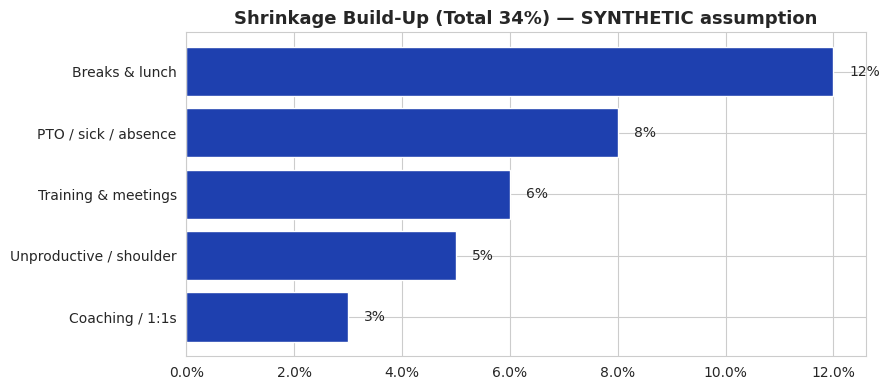

,dow,interval_30,agents_required,scheduled_fte
0,Monday,0,2,4
1,Monday,30,2,4
2,Monday,60,1,2
3,Monday,90,1,2
4,Monday,120,1,2
5,Monday,150,1,2
6,Monday,180,1,2
7,Monday,210,1,2
8,Monday,240,1,2
9,Monday,270,1,2


In [12]:
SHRINKAGE = {
    "Breaks & lunch":            0.12,
    "Training & meetings":       0.06,
    "Coaching / 1:1s":           0.03,
    "PTO / sick / absence":      0.08,
    "Unproductive / shoulder":   0.05,
}
TOTAL_SHRINKAGE = sum(SHRINKAGE.values())
print(f"Total shrinkage: {TOTAL_SHRINKAGE:.0%}")

# shrinkage uplift
plan["scheduled_fte"] = np.ceil(plan["agents_required"] / (1 - TOTAL_SHRINKAGE)).astype(int)

# visualize the build-up
fig, ax = plt.subplots(figsize=(9,4))
comp = pd.Series(SHRINKAGE).sort_values()
ax.barh(comp.index, comp.values*100, color="#1E40AF")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title(f"Shrinkage Build-Up (Total {TOTAL_SHRINKAGE:.0%}) — SYNTHETIC assumption")
for i,v in enumerate(comp.values):
    ax.text(v*100+0.3, i, f"{v:.0%}", va="center", fontsize=10)
plt.tight_layout(); plt.show()

plan[["dow","interval_30","agents_required","scheduled_fte"]].head(12)


## 7. Staffing Gap Analysis

The payoff of the whole pipeline: compare the **required** scheduled FTEs against what is **actually scheduled**, interval by interval, and flag the gaps. Over-staffing wastes money; under-staffing misses SLA and burns out the team.

> **SYNTHETIC SCHEDULE:** Real centers schedule in shift blocks, not to the per-interval ideal, so coverage is "lumpy." We emulate this by scheduling a smoothed, shift-shaped headcount: a flat core staff across open hours plus a daytime bump, deliberately *not* matching the curve. This produces the realistic over/under pattern a WFM analyst hunts for.


In [13]:
# Focus on one representative weekday for the gap demonstration
demo_dow = "Tuesday"
d = plan[plan["dow"] == demo_dow].sort_values("interval_30").reset_index(drop=True)

# --- synthetic shift-based schedule (lumpy, not curve-matched) ---
# Built from overlapping shift blocks so total headcount is roughly right
# but the *distribution* lags the forecast curve -- the realistic failure mode.
m = d["interval_30"]
early = ((m >= 7*60)  & (m < 16*60)).astype(int) * 12   # early shift 07:00-16:00
mid   = ((m >= 10*60) & (m < 19*60)).astype(int) * 8    # mid shift   10:00-19:00 (lands AFTER the 10:00 peak)
late  = ((m >= 15*60) & (m < 24*60)).astype(int) * 7    # late shift  15:00-24:00
d["scheduled_actual"] = (early + mid + late)

d["gap"] = d["scheduled_actual"] - d["scheduled_fte"]   # +ve = overstaffed, -ve = understaffed

# recompute the service level you'd actually deliver with the lumpy schedule
def delivered_sl(row):
    on_phone = row["scheduled_actual"] * (1 - TOTAL_SHRINKAGE)
    A = row["workload_erlangs"]
    if A <= 0:
        return 1.0
    return service_level(A, max(1, int(np.floor(on_phone))), TARGET_SEC, AHT_SECONDS)

d["delivered_sl"] = d.apply(delivered_sl, axis=1)
d[["interval_30","forecast_calls","scheduled_fte","scheduled_actual","gap","delivered_sl"]].iloc[14:40:2]


,interval_30,forecast_calls,scheduled_fte,scheduled_actual,gap,delivered_sl
14,420,16.54,7,12,5,0.99
16,480,36.49,13,12,-1,0.75
18,540,56.03,17,12,-5,0.00
20,600,73.34,20,20,0,0.81
22,660,59.84,17,20,3,0.95
24,720,54.91,17,20,3,0.97
26,780,51.27,16,20,4,0.98
28,840,65.87,19,20,1,0.90
30,900,60.98,19,27,8,1.00
32,960,61.85,19,15,-4,0.31


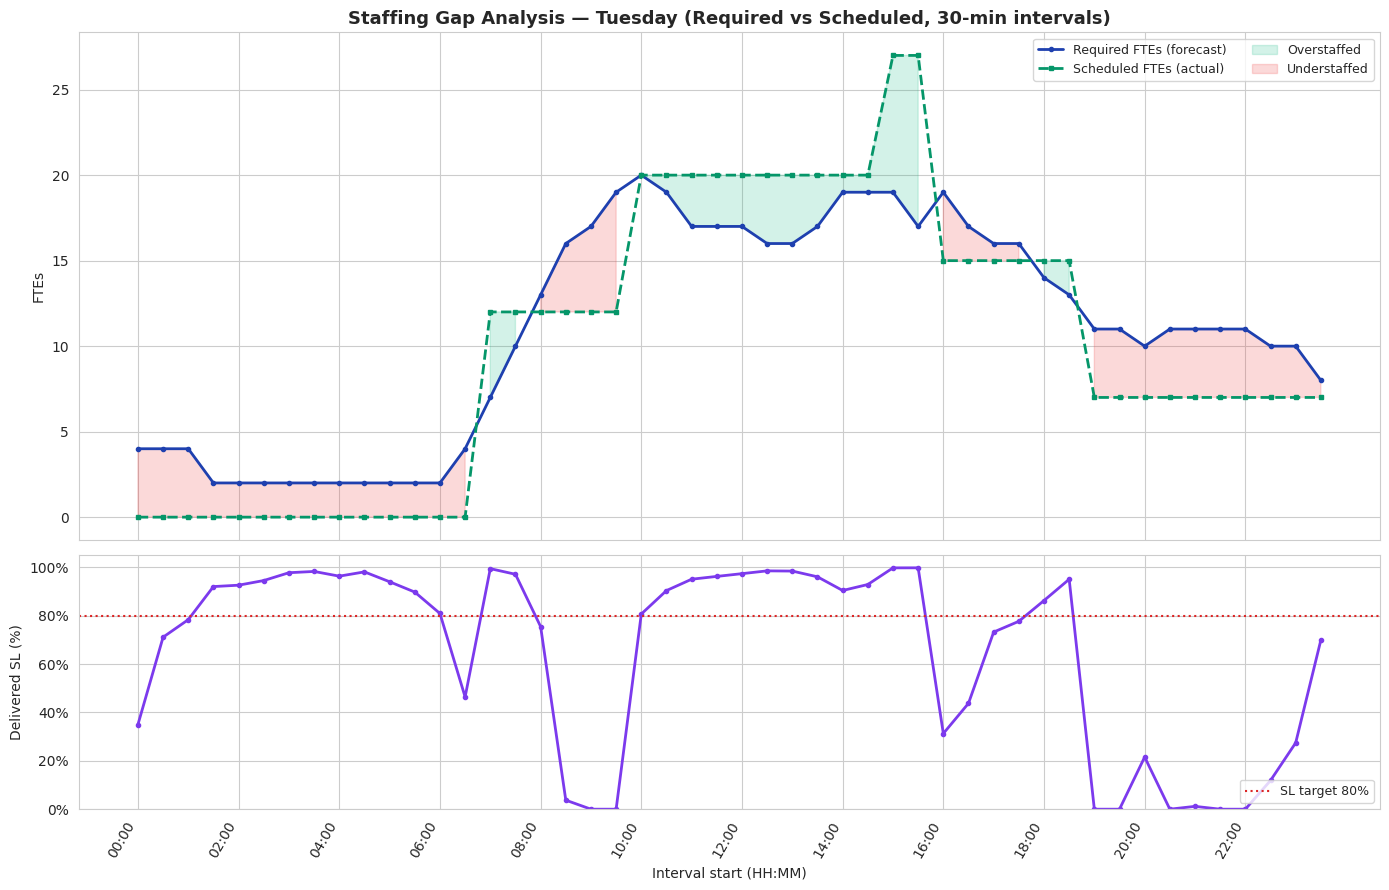

In [14]:
xlab = [hhmm(m) for m in d["interval_30"]]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                               gridspec_kw={"height_ratios":[2,1]})

# top: required vs scheduled
ax1.plot(xlab, d["scheduled_fte"], color="#1E40AF", lw=2, marker="o", ms=3, label="Required FTEs (forecast)")
ax1.plot(xlab, d["scheduled_actual"], color="#059669", lw=2, ls="--", marker="s", ms=3, label="Scheduled FTEs (actual)")
ax1.fill_between(range(len(d)), d["scheduled_fte"], d["scheduled_actual"],
                 where=(d["scheduled_actual"] >= d["scheduled_fte"]), color="#10B981", alpha=0.18, label="Overstaffed")
ax1.fill_between(range(len(d)), d["scheduled_fte"], d["scheduled_actual"],
                 where=(d["scheduled_actual"] <  d["scheduled_fte"]), color="#EF4444", alpha=0.20, label="Understaffed")
ax1.set_title(f"Staffing Gap Analysis — {demo_dow} (Required vs Scheduled, 30-min intervals)")
ax1.set_ylabel("FTEs"); ax1.legend(loc="upper right", ncol=2, fontsize=9)

# bottom: delivered service level
ax2.plot(xlab, d["delivered_sl"]*100, color="#7C3AED", lw=2, marker="o", ms=3)
ax2.axhline(TARGET_SL*100, color="#DC2626", ls=":", lw=1.5, label=f"SL target {TARGET_SL:.0%}")
ax2.set_ylabel("Delivered SL (%)"); ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(loc="lower right", fontsize=9)

step = 4
ax2.set_xticks(range(0, len(xlab), step)); ax2.set_xticklabels(xlab[::step], rotation=60, ha="right")
ax2.set_xlabel("Interval start (HH:MM)")
plt.tight_layout(); plt.show()


Read this the way a WFM analyst would on a Monday morning:

- **Red bands (understaffed)** — typically the morning ramp and peak, where a lumpy shift schedule lags the forecast curve. These are the intervals where SLA breaks and customers wait. The fix is shift-start staggering or a part-time tranche landing at the peak.
- **Green bands (overstaffed)** — usually the late evening and shoulders, where the flat core over-covers low volume. These are cost-reduction or offline-work (training, coaching) opportunities.
- **Bottom panel** — the service level you'd actually deliver. Where the purple line dips below the red SLA line, the schedule fails the 80/20 target *regardless* of the daily headcount being "enough" — proving the WFM point that **total headcount can be right while the intraday distribution is wrong.**


In [15]:
# summary scorecard for the day
open_intervals = d[d["scheduled_actual"] > 0]
under = (open_intervals["gap"] < 0).sum()
over  = (open_intervals["gap"] > 0).sum()
sla_miss = (open_intervals["delivered_sl"] < TARGET_SL).sum()
agg_sl = np.average(open_intervals["delivered_sl"], weights=open_intervals["forecast_calls"])

print(f"=== {demo_dow} WFM Scorecard ===")
print(f"Staffed intervals          : {len(open_intervals)}")
print(f"Understaffed intervals     : {under}  ({under/len(open_intervals):.0%})")
print(f"Overstaffed intervals      : {over}  ({over/len(open_intervals):.0%})")
print(f"Intervals missing SLA      : {sla_miss}  ({sla_miss/len(open_intervals):.0%})")
print(f"Volume-weighted day SL     : {agg_sl:.1%}   (target {TARGET_SL:.0%})")
print(f"Total scheduled FTE-intervals: {int(open_intervals['scheduled_actual'].sum())}")
print(f"Total required  FTE-intervals: {int(open_intervals['scheduled_fte'].sum())}")


=== Tuesday WFM Scorecard ===
Staffed intervals          : 34
Understaffed intervals     : 18  (53%)
Overstaffed intervals      : 15  (44%)
Intervals missing SLA      : 18  (53%)
Volume-weighted day SL     : 62.4%   (target 80%)
Total scheduled FTE-intervals: 486
Total required  FTE-intervals: 494


## 8. Summary

This notebook runs the full WFM planning chain on real interval-level arrival data:

1. **Forecast** — interval-level call volume via a transparent profile-ratio method, validated on a holdout and reported with the volume-weighted error metric (WAPE) that WFM teams actually track.
2. **Workload** — converted calls to offered load using an explicit AHT assumption.
3. **Erlang C** — sized agents-on-phone to an 80/20 service-level target under a 90% occupancy ceiling.
4. **Shrinkage** — uplifted on-phone requirement to scheduled FTEs with a fully decomposed 34% shrinkage build-up.
5. **Gap analysis** — compared required vs. a realistic lumpy shift schedule, surfaced over/under-staffed intervals, and showed delivered service level interval-by-interval.

**Methodology, not platform.** The same logic powers commercial WFM suites (NICE, Verint, Calabrio). This notebook demonstrates the underlying methodology directly in Python — the forecasting, queueing, and capacity-planning reasoning that sits beneath any tool.

**Extensions a production build would add:** abandonment-aware queueing (Erlang A/X), intraday re-forecasting, multi-skill / blended workload, shift-bidding optimization, and a what-if layer for AHT/shrinkage sensitivity.

---

*Data: "Anonymous Bank" call-center dataset, SEE Lab, Technion (Prof. Avi Mandelbaum), via the Rfssa data mirror. WFM overlay (AHT, shrinkage, service-level target, schedule) is synthetic and labeled throughout. Business logic and operational framing by the author; AI assisted with Python syntax and plotting.*
